In [1]:
%load_ext autoreload
%autoreload 2

# Imports

In [1]:
import ee
import geemap

In [2]:
try:
    ee.Initialize()
except:
    # need to authenticate with your credential at the first time
    ee.Authenticate()
    ee.Initialize()

In [3]:
def maskS2clouds(image):
    qa = image.select('QA60')
    neighbor_size = 30         # 30 pixels or 300 meters
    quality_threshold = 0.05   # above 5% of cloud or shadow would be masked
    
    # Bits 10 and 11 are clouds and cirrus, respectively.
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    
    # Both flags should be set to zero, indicating clear conditions.Both flags should be set to zero, indicating clear conditions.
    mask = qa.bitwiseAnd(cloudBitMask).eq(0) \
      .And(qa.bitwiseAnd(cirrusBitMask).eq(0))
    
    """
    *  Account for shadow effect and use neighborhood average
    """
    # calculate the neighborhood average (NA) fraction of cloud (SCL 8-10)
    cldPrbNA = image.select('SCL').gte(8).And(image.select('SCL').lte(10)) \
        .reduceNeighborhood(**{
            'reducer': ee.Reducer.mean(),
            'kernel': ee.Kernel.circle(neighbor_size)
        }).rename('cldPrbNA')
    
    # calculate the neighborhood average (NA) fraction of shadow (SCL 3)
    cldShadowNA = image.select('SCL').eq(3) \
        .reduceNeighborhood(**{
            'reducer': ee.Reducer.mean(),
            'kernel': ee.Kernel.circle(neighbor_size)
        }).rename('cldShadowNA')
    
    # the NA fraction of clouds and shadow
    cldTotalNA = cldPrbNA.add(cldShadowNA)
    
    # Update the mask, cldTotalNA should be lower than quality_threshold defined above
    mask = mask.And(cldTotalNA.lt(quality_threshold))
    return image.updateMask(mask).divide(10_000) \
        .addBands(cldPrbNA).addBands(cldShadowNA) \
        .copyProperties(image, ['system:time_start'])

In [7]:
def addVegetationIndices(image):
    image = image.clip(MtPleasant)
    
    NIRv = image.expression(
        '((NIR - RED) / (NIR + RED)) * NIR',
        { 
          'NIR': image.select('B8'),
          'RED': image.select('B4')
        }).rename('NIRv')
    
    EVI = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 6 * RED + 7.5 * BLUE + 1))',
        {
            'NIR': image.select('B8'),
            'RED': image.select('B4'),
            'BLUE': image.select('B2')
        }).rename('EVI')
    
    # Return the masked image with NIRv and EVI bands.
    return image.addBands(NIRv).addBands(EVI)

In [8]:
# Define study region (this is half of Mt Pleasant)
MtPleasant = ee.Geometry.Polygon(
    [-76.39092979365925, 42.47111031803205,
     -76.39092979365925, 42.46458902246419,
     -76.37702522212605, 42.46458902246419,
     -76.37702522212605, 42.47111031803205], None, False)

# Setup Sentinel-2 image collection over study region with low(ish) cloud cover
site_images = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
    .filterBounds(MtPleasant) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 80)) \
    .map(maskS2clouds).map(addVegetationIndices).select(['EVI', 'NIRv'])

In [9]:
# Define study region (this is half of Mt Pleasant)
ArnotForest ArnotForest = ee.Geometry.Polygon(
    [-76.635694, 42.287797,
     -76.615694, 42.287797, 
     -76.615694, 42.300797, 
     -76.635694, 42.300797],None, False);

# Setup Sentinel-2 image collection over study region with low(ish) cloud cover
site_images = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
    .filterBounds(ArnotForest) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 80)) \
    .map(maskS2clouds).map(addVegetationIndices).select(['EVI', 'NIRv'])

In [11]:
# Download data
geemap.ee_export_image_collection(site_images, out_dir='../data/images_ArnotForest/')

Total number of images: 319

Exporting 1/319: 20181227T155651_20181227T155851_T18TUM.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\camer\GEE Work\DefoliationClassification\data\images_ArnotForest\20181227T155651_20181227T155851_T18TUM.tif


Exporting 2/319: 20190106T155631_20190106T155840_T18TUM.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\camer\GEE Work\DefoliationClassification\data\images_ArnotForest\20190106T155631_20190106T155840_T18TUM.tif


Exporting 3/319: 20190111T155629_20190111T155951_T18TUM.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\camer\GEE Work\DefoliationClassification\data\images_ArnotForest\20190111T155629_20190111T155951_T18TUM.tif


Exporting 4/319: 20190114T160619_20190114T160808_T18TUM.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\camer\GEE Work\DefoliationClassification\data\images_ArnotForest\20190114T160619_20190114T160808_T18TUM.tif


Exporting 5/319: 20190121T155549_201901

In [18]:
site_images = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
    .filterBounds(MtPleasant) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 80)) \
    .map(maskS2clouds).select(['B4', 'B3', 'B2'])
geemap.ee_export_image(site_images.mosaic(), filename='../data/results_MtPleasant/study_area.tif', region=MtPleasant)

Generating URL ...
An error occurred while downloading.
Image.clipToBoundsAndScale: The geometry for image clipping must be bounded.


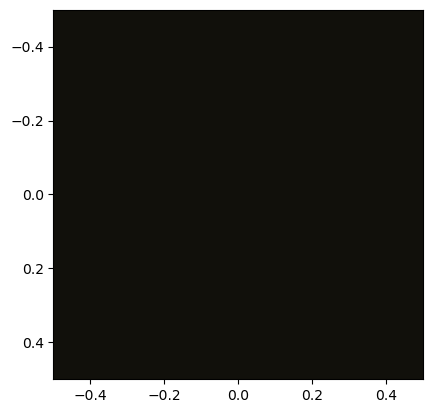

In [19]:
import rasterio
import numpy as np
import xarray as xr

with rasterio.open('../data/results_MtPleasant/study_area.tif', 'r') as src:
    im = src.read()
    # read image into ndarray

    # transpose the matrix from (band, row, col) to (row, col, band)
    im = np.transpose(im, [1,2,0])

    # set null values
    im[im == 0.] = np.nan

    # get coordinates
    # first axis, from north to south
    lat_array = np.linspace(src.bounds[3],src.bounds[1],im.shape[0])
    # second axis, from west to east
    lon_array = np.linspace(src.bounds[0],src.bounds[2],im.shape[1])

    src.close()
    
    da = xr.Dataset({'B4':(('lat','lon'),im[:,:,0]), 'B3':(('lat','lon'),im[:,:,1]), 'B2':(('lat','lon'),im[:,:,2])},
                     coords={'lat':lat_array,'lon':lon_array})
    

import matplotlib.pyplot as plt
plt.imshow(im)

In [23]:
da.to_dataframe()

,,B4,B3,B2
lat,lon,,,
43.0,-77.0,0.0682,0.0647,0.0459
